# PCA on the mock surface residuals

End-to-end PCA on the parallel-shift-stripped diff panels
(`data/mock/{rate, atm_vol, skew_p2, skew_n2}_residual.pkl`,
produced by `data/pipeline.py`). The residual is the daily move
with the realised-std-weighted cross-sectional parallel shift
removed, so the surviving structure is what's left after the
dominant level move is hedged out — i.e. the slope / curvature /
shape factors a desk would actually trade.

## 1. Setup

Load the residual panels for all four surfaces. The pkls share the
canonical long format `[date, expiry, tenor, value]`, so we pivot to
a wide `date × MultiIndex(expiry, tenor)` panel with the standard
`load_long` / `to_wide` pair.

In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pca import load_long, to_wide, run_pca, reconstruct, EXPIRY_LABELS, TENOR_LABELS

sns.set_theme(style="whitegrid")

residuals = {name: to_wide(load_long(f"../data/mock/{name}_residual.pkl"))
             for name in ("rate", "atm_vol", "skew_p2", "skew_n2")}

for name, r in residuals.items():
    print(f"{name:10s}: {r.shape}")

## 2. PCA on the rate residual

Fit a 10-component PCA on the rate-residual panel. Scree plot with
horizontal guides at 80% and 95% cumulative variance.

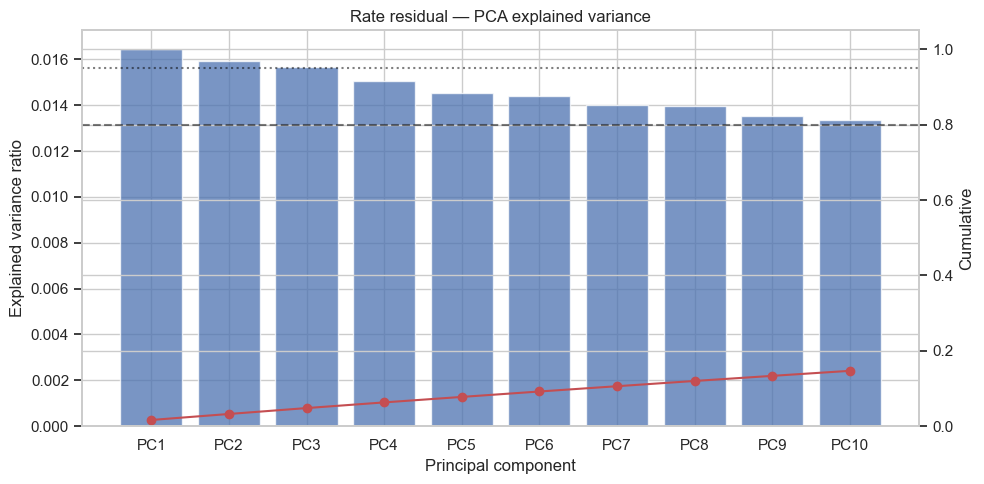

  PC  Explained %  Cumulative %
 PC1         1.64          1.64
 PC2         1.59          3.23
 PC3         1.57          4.80
 PC4         1.51          6.31
 PC5         1.45          7.76
 PC6         1.44          9.20
 PC7         1.40         10.60
 PC8         1.39         11.99
 PC9         1.35         13.35
PC10         1.33         14.68


In [2]:
rate_residual = residuals["rate"]
rate_scores, rate_loadings, rate_explained = run_pca(rate_residual, n_components=10, standardize=True)

explained_df = pd.DataFrame({
    "PC": rate_explained.index,
    "Explained %": (rate_explained.values * 100).round(2),
    "Cumulative %": (rate_explained.cumsum().values * 100).round(2),
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(rate_explained.index, rate_explained.values, alpha=0.75)
ax2 = ax.twinx()
ax2.plot(rate_explained.index, rate_explained.cumsum().values, color="C3", marker="o")
ax2.axhline(0.80, color="black", linestyle="--", alpha=0.5)
ax2.axhline(0.95, color="black", linestyle=":", alpha=0.5)
ax2.set_ylim(0, 1.05)
ax.set_ylabel("Explained variance ratio")
ax2.set_ylabel("Cumulative")
ax.set_title("Rate residual — PCA explained variance")
ax.set_xlabel("Principal component")
plt.tight_layout()
plt.show()

print(explained_df.to_string(index=False))

**Interpretation.** The parallel shift has already been stripped,
so the level mode is no longer the dominant PC. What's left to
explain is the cross-sectional variation in daily moves *around*
the global shift — slope and curvature in tenor for rates, plus
per-cell idiosyncratic noise. The cumulative-variance curve rises
more gradually than it would on a level panel.

## 3. Rate PC loading heatmaps

Plot the first three PCs' loadings as `expiry × tenor` grids with a
diverging colormap centred at 0. Rows / columns sit in canonical
order; with the parallel shift already stripped, the patterns that
show up first are slope (left/right sign flip across tenors) and
curvature (belly vs. wings).

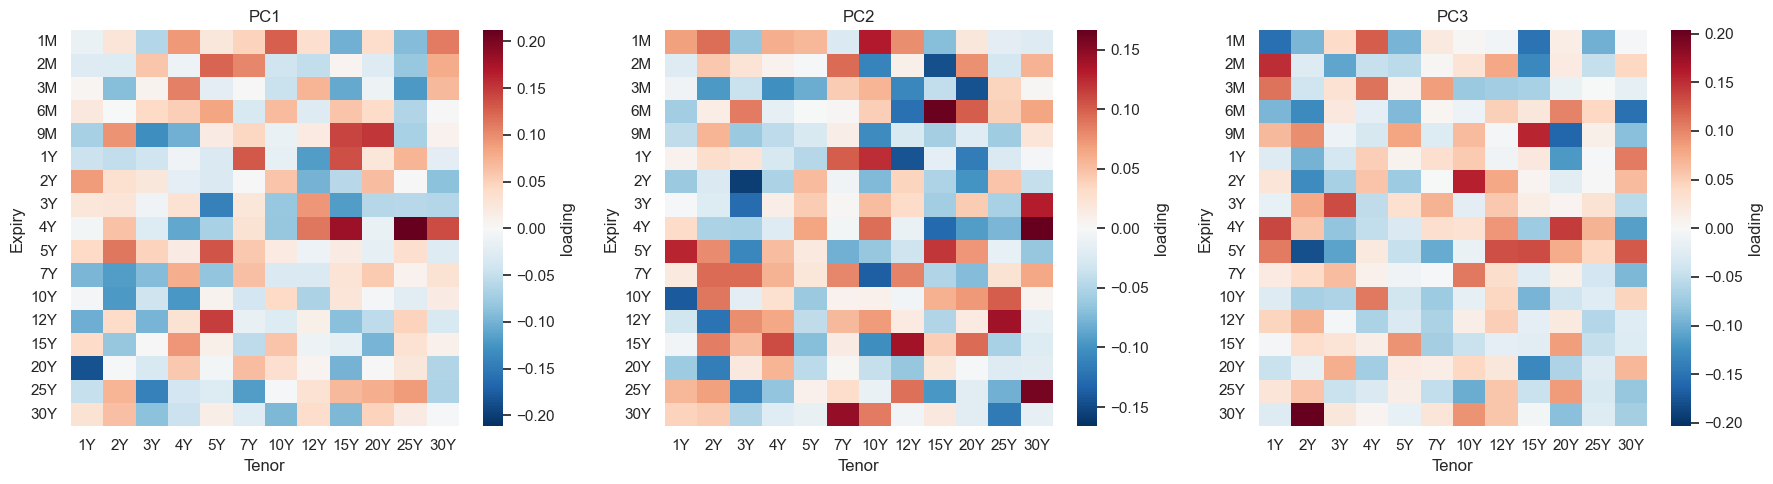

In [3]:
def loading_grid(loadings, pc):
    return loadings.loc[pc].unstack("tenor").reindex(
        index=[e for e in EXPIRY_LABELS if e in loadings.columns.get_level_values("expiry")],
        columns=[t for t in TENOR_LABELS if t in loadings.columns.get_level_values("tenor")],
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pc in zip(axes, ["PC1", "PC2", "PC3"]):
    grid = loading_grid(rate_loadings, pc)
    vmax = float(grid.abs().max().max())
    sns.heatmap(grid, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={"label": "loading"})
    ax.set_title(pc); ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")
plt.tight_layout(); plt.show()

**Interpretation.** With the parallel shift gone, the top PCs
encode the non-level structure of daily moves:

* **PC1.** Typically a slope mode — short tenors load one way,
  long tenors the other.
* **PC2.** Curvature — middle tenors against the wings (butterfly).
* **PC3.** Higher-order shape (often a second-derivative tilt).

Exact labelling depends on the realised data; the structure shown
in the heatmaps is what dictates the interpretation.

## 4. PCA on the ATM-vol residual

Same analysis on the vol-residual panel. The vol surface carries
a non-trivial expiry hump that survives the parallel-shift strip,
so the loadings here have richer shape than the rate residual.

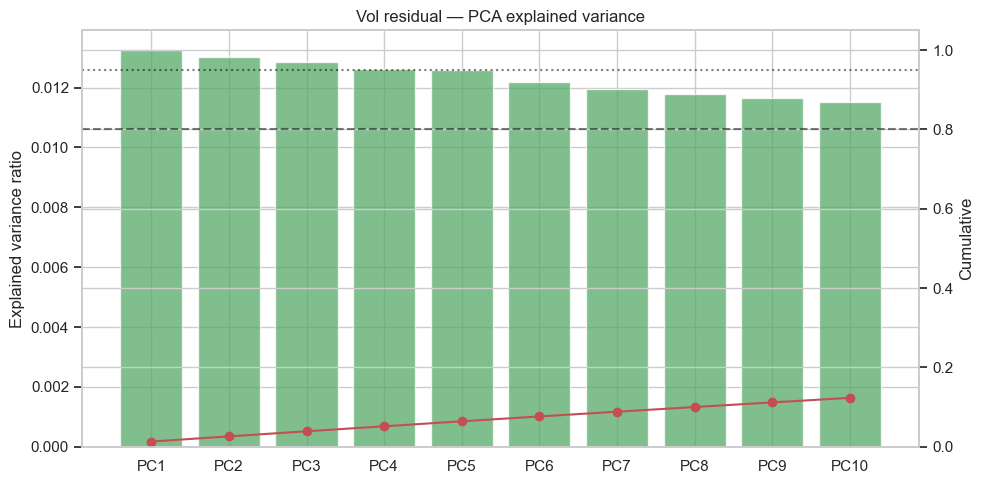

  PC  Explained %  Cumulative %
 PC1         1.33          1.33
 PC2         1.30          2.63
 PC3         1.28          3.91
 PC4         1.26          5.17
 PC5         1.26          6.43
 PC6         1.22          7.65
 PC7         1.19          8.85
 PC8         1.18         10.02
 PC9         1.17         11.19
PC10         1.15         12.34


In [4]:
vol_residual = residuals["atm_vol"]
vol_scores, vol_loadings, vol_explained = run_pca(vol_residual, n_components=10, standardize=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(vol_explained.index, vol_explained.values, alpha=0.75, color="C2")
ax2 = ax.twinx()
ax2.plot(vol_explained.index, vol_explained.cumsum().values, color="C3", marker="o")
ax2.axhline(0.80, color="black", linestyle="--", alpha=0.5)
ax2.axhline(0.95, color="black", linestyle=":", alpha=0.5)
ax2.set_ylim(0, 1.05)
ax.set_ylabel("Explained variance ratio")
ax2.set_ylabel("Cumulative")
ax.set_title("Vol residual — PCA explained variance")
plt.tight_layout(); plt.show()

vol_explained_df = pd.DataFrame({
    "PC": vol_explained.index,
    "Explained %": (vol_explained.values * 100).round(2),
    "Cumulative %": (vol_explained.cumsum().values * 100).round(2),
})
print(vol_explained_df.to_string(index=False))

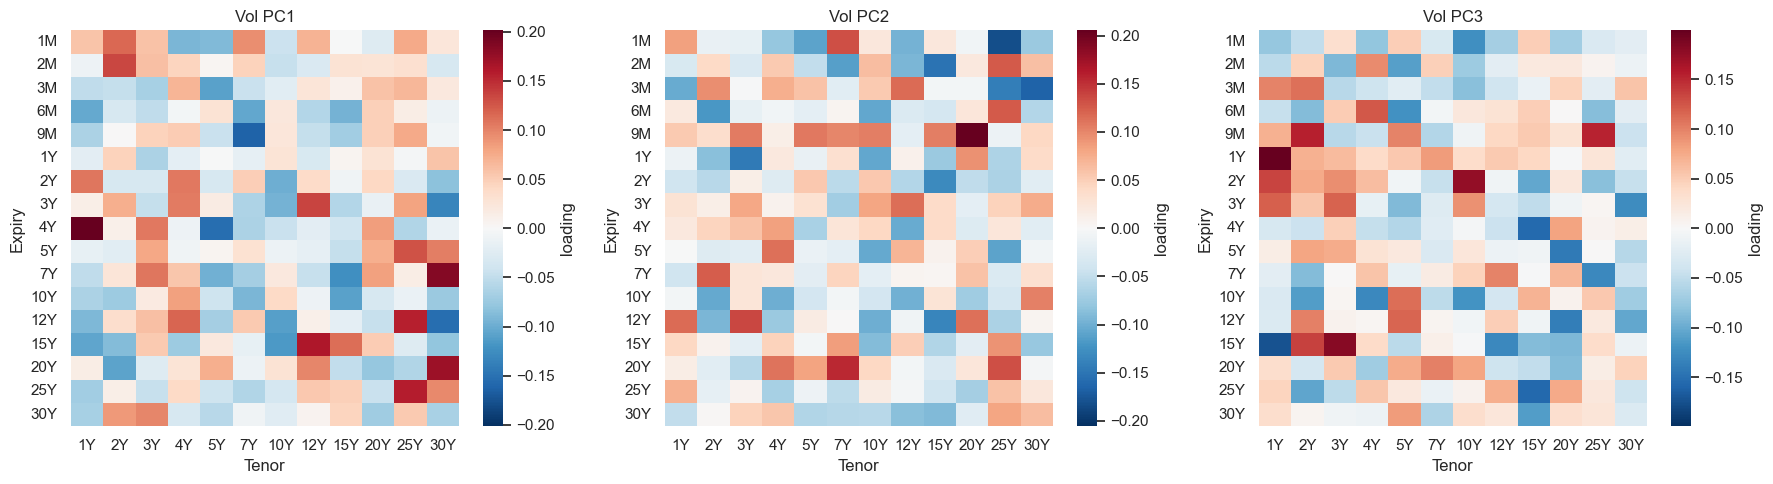

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pc in zip(axes, ["PC1", "PC2", "PC3"]):
    grid = loading_grid(vol_loadings, pc)
    vmax = float(grid.abs().max().max())
    sns.heatmap(grid, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={"label": "loading"})
    ax.set_title(f"Vol {pc}"); ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")
plt.tight_layout(); plt.show()

**Vol vs rate residual.** The vol residual spreads variance
across more PCs than the rate residual — the per-cell vol-of-vol
injects more idiosyncratic noise. The leading vol PC loading map
still shows the expiry hump (intermediate expiries load
differently from the wings), which doesn't appear in the rate
residual.

## 5. Rate vs vol PC cross-correlation

How much do the rate and vol residual PCs share information? The
mock DGP couples vol innovations to the level innovation with
ρ = −0.35, but the level component has been stripped from both
panels — so any surviving correlation comes from cross-cell
co-movement at the residual level.

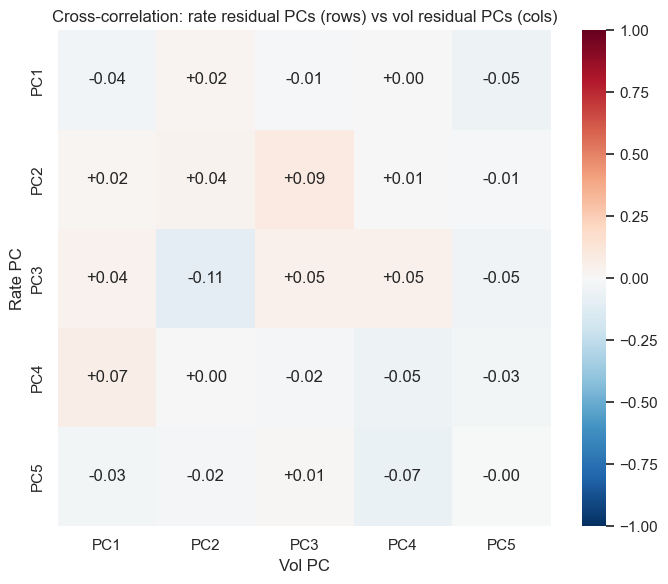

rate PC1 vs vol PC1: -0.039
rate PC2 vs vol PC2: +0.038


In [6]:
common = rate_scores.index.intersection(vol_scores.index)
rs = rate_scores.loc[common].iloc[:, :5]
vs = vol_scores.loc[common].iloc[:, :5]
cross = pd.DataFrame(
    {vc: rs.corrwith(vs[vc]) for vc in vs.columns}
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cross, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Cross-correlation: rate residual PCs (rows) vs vol residual PCs (cols)")
ax.set_xlabel("Vol PC"); ax.set_ylabel("Rate PC")
plt.tight_layout(); plt.show()

print(f"rate PC1 vs vol PC1: {cross.loc['PC1','PC1']:+.3f}")
print(f"rate PC2 vs vol PC2: {cross.loc['PC2','PC2']:+.3f}")

**Interpretation.** Cells with `|corr| > 0.3` are the genuinely
informative cross-surface links at the residual level. Most
entries sit near zero because the dominant level coupling has
been removed from both sides; what survives is shape co-movement
(e.g. rate slope ↔ vol hump shifts).

## 6. Reconstruction quality

How many PCs do we need to faithfully represent the rate
residual? Reconstruct with 1, 3, and 5 PCs and look at per-pair
mean absolute error on a common colour scale.

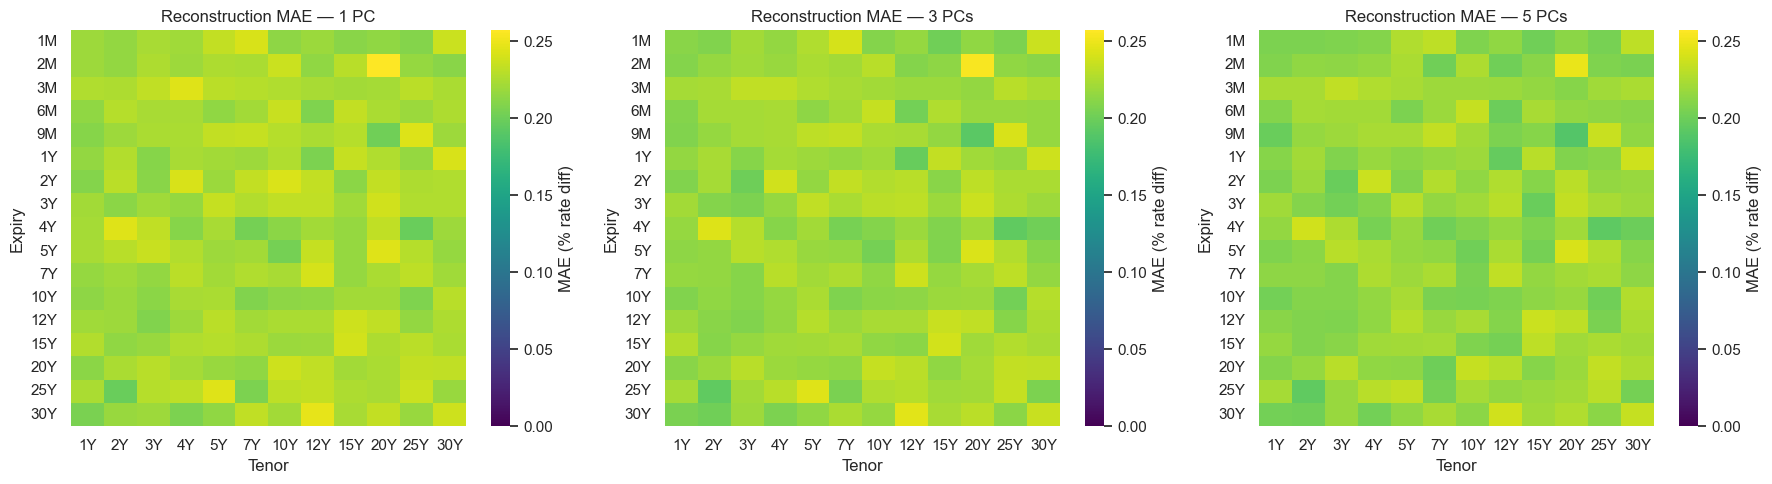

Average MAE across all pairs:
  1 PC: 0.2236
  3 PCs: 0.2200
  5 PCs: 0.2165


In [7]:
errors = {}
rate_clean = rate_residual.dropna(axis=1)
for k in [1, 3, 5]:
    recon = reconstruct(rate_scores, rate_loadings, rate_residual, n_components=k)
    per_pair_mae = (rate_clean - recon).abs().mean(axis=0)
    grid = per_pair_mae.unstack("tenor").reindex(
        index=[e for e in EXPIRY_LABELS if e in per_pair_mae.index.get_level_values("expiry")],
        columns=[t for t in TENOR_LABELS if t in per_pair_mae.index.get_level_values("tenor")],
    )
    errors[k] = grid

vmax = max(g.values.max() for g in errors.values())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (k, grid) in zip(axes, errors.items()):
    sns.heatmap(grid, ax=ax, cmap="viridis", vmin=0, vmax=vmax,
                cbar_kws={"label": "MAE (% rate diff)"})
    ax.set_title(f"Reconstruction MAE — {k} PC{'s' if k > 1 else ''}")
    ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")
plt.tight_layout(); plt.show()

print("Average MAE across all pairs:")
for k, g in errors.items():
    print(f"  {k} PC{'s' if k > 1 else ''}: {g.values.mean():.4f}")

**Interpretation.** Reconstruction is in residual-diff units
(% rate move per day after the parallel shift is removed). 1 PC
captures the dominant residual mode; PC2/PC3 fill in shape
detail; past 3 PCs the remaining error is at the idiosyncratic
floor.

## 7. Stability check — expanding window

Fit PCA on the first 60% of dates, then on the full sample, and
compare the PC1 loadings of the rate residual. If the structure
is stable, loadings should track closely across windows. Sign is
arbitrary in PCA, so we sign-align by inner product before
differencing.

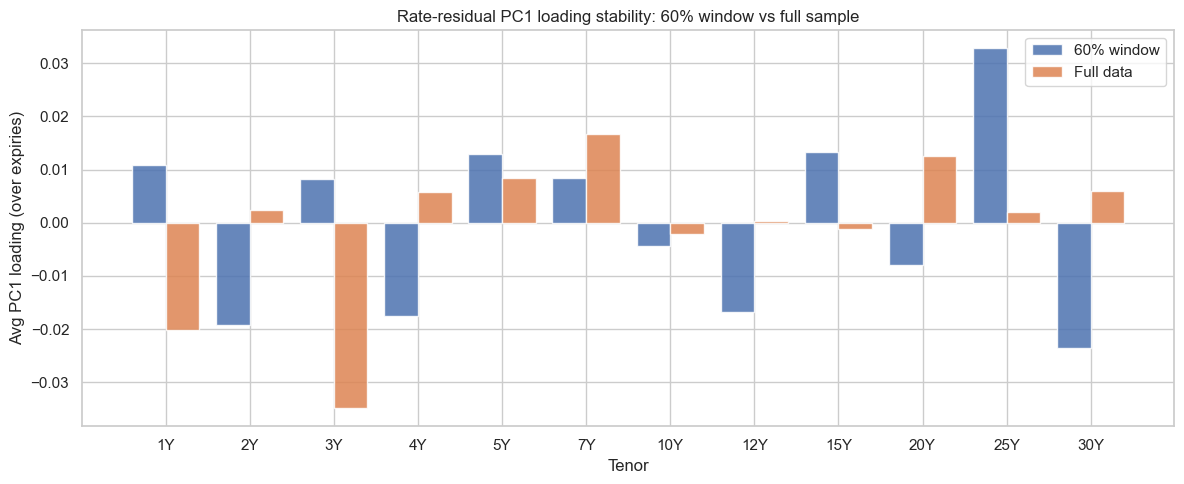

Avg |loading diff|: 0.0205
Max |loading diff|: 0.0430


In [8]:
n_train = int(0.6 * len(rate_residual))
rate_train = rate_residual.iloc[:n_train]
rs_t, rl_t, re_t = run_pca(rate_train, n_components=3, standardize=True)

la = rl_t.loc["PC1"]; lb = rate_loadings.loc["PC1"]
if np.corrcoef(la.values, lb.values)[0, 1] < 0:
    la = -la

by_t_train = la.groupby("tenor").mean().reindex([t for t in TENOR_LABELS if t in la.index.get_level_values("tenor")])
by_t_full = lb.groupby("tenor").mean().reindex(by_t_train.index)

x = np.arange(len(by_t_train)); width = 0.4
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, by_t_train.values, width, label="60% window", alpha=0.85)
ax.bar(x + width/2, by_t_full.values, width, label="Full data", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(by_t_train.index)
ax.set_xlabel("Tenor"); ax.set_ylabel("Avg PC1 loading (over expiries)")
ax.set_title("Rate-residual PC1 loading stability: 60% window vs full sample")
ax.legend(); plt.tight_layout(); plt.show()

diff = (by_t_full - by_t_train).abs()
print(f"Avg |loading diff|: {diff.mean():.4f}")
print(f"Max |loading diff|: {diff.max():.4f}")

**Interpretation.** Bars at each tenor should be visually
indistinguishable if the residual structure is stationary. Small
loading drift means the dominant residual mode generalises
out-of-sample and can be frozen as a fixed factor.

## 8. Stability check — three time slabs

A stronger stability check than the expanding window above: split
the date axis into three non-overlapping segments — first 30%,
middle 40%, last 30% — fit PCA on each, and compare loadings
across all three. If the basis is genuinely stationary, the three
segments should yield essentially the same loadings (up to sign).

Comparison is the absolute cosine similarity of the loading
vectors (sign is arbitrary in PCA). The diagonal of the resulting
K × K matrix tells you whether *each* PC repeats; significant
off-diagonal mass means the PCs reorder across segments but the
subspace may still be the same.

In [ ]:
def slab_pca(panel, k=3):
    n = len(panel)
    slabs = {
        "first_30%": panel.iloc[:int(0.3 * n)],
        "mid_40%":   panel.iloc[int(0.3 * n):int(0.7 * n)],
        "last_30%":  panel.iloc[int(0.7 * n):],
    }
    return {name: run_pca(slab, n_components=k, standardize=True)[1]
            for name, slab in slabs.items()}

def abs_cos_sim(L_a, L_b):
    a = L_a.values; b = L_b.values
    a_n = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_n = b / np.linalg.norm(b, axis=1, keepdims=True)
    return np.abs(a_n @ b_n.T)

K = 3
slab_pairs = [("first_30%", "mid_40%"),
              ("mid_40%",   "last_30%"),
              ("first_30%", "last_30%")]
panels = [("rate", rate_residual), ("vol", vol_residual)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, (panel_name, panel) in enumerate(panels):
    fits = slab_pca(panel, k=K)
    for ax, (a, b) in zip(axes[row], slab_pairs):
        M = abs_cos_sim(fits[a], fits[b])
        sns.heatmap(M, ax=ax, annot=True, fmt=".2f", cmap="viridis",
                    vmin=0, vmax=1, cbar=False,
                    xticklabels=[f"PC{i+1}" for i in range(K)],
                    yticklabels=[f"PC{i+1}" for i in range(K)])
        ax.set_title(f"{panel_name} residual — |cos|\n{a} (rows) ↔ {b} (cols)",
                     fontsize=10)
plt.tight_layout(); plt.show()

# Diagonal summary: PC-by-PC stability per pair, per surface.
rows = []
for panel_name, panel in panels:
    fits = slab_pca(panel, k=K)
    for a, b in slab_pairs:
        M = abs_cos_sim(fits[a], fits[b])
        rows.append({
            "surface": panel_name,
            "pair":    f"{a} ↔ {b}",
            **{f"PC{i+1}": float(M[i, i]) for i in range(K)},
        })
print(pd.DataFrame(rows).round(3).to_string(index=False))

**Interpretation.** Diagonal entries near 1.0 mean the same PC
structure repeats across time slabs — loadings are stationary and
the basis can be frozen as fixed features. Significant off-diagonal
mass (e.g. segment A's PC2 best matches segment B's PC1) signals PC
reordering: the subspace is preserved but the per-PC labelling
isn't. Diagonal values well below ~0.9 mean the basis itself drifts
between segments and shouldn't be treated as a stable factor model.

## 9. Summary

* **Rate residual:** parallel shift already removed; the
  surviving structure is slope / curvature / shape, captured
  cleanly by the top few PCs.
* **Vol residual:** richer than rates — the expiry hump shows up
  in the loadings even after the level move is gone.
* **Cross-correlation:** weaker than on the raw panel since the
  shared level coupling has been stripped from both sides.
* **Stability:** rate-residual PC1 loadings on the 60% window
  match the full sample tenor-by-tenor (Section 7), and the
  three-slab cosine-similarity check (Section 8) shows whether
  the basis is stationary across both surfaces.